# Orion

## Getting Started

### Here we'll go through a complete rocket trajectory simulation for Orion, in the case of a Nominal Flight. 
#### Let's start by importing RocketPy

In [1]:
%pip install rocketpy
from rocketpy import *
import numpy as np

Note: you may need to restart the kernel to use updated packages.


## Setting Up the Simulation

### Environment

In [2]:
env = Environment(latitude=-21.90795, longitude=-48.96156, elevation=495)

In [3]:

env.set_date(
    (2026, 9, 4, 15)
)  # Hour given in UTC time

In [4]:
env.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=None,
    temperature=None, #Leaving temperature and pressure in None means we are getting values from ISA
    wind_u=2.77778,
    wind_v=0
    )


Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5452 m/s²


Launch Site Details

Launch Date: 2026-09-04 15:00:00 UTC
Launch Site Latitude: -21.90795°
Launch Site Longitude: -48.96156°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 90584.06 W    7572074.74 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 495.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 2.78 m/s
Surface Wind Direction: 270.00°
Surface Wind Heading: 90.00°
Surface Pressure: 955.47 hPa
Surface Temperature: 284.94 K
Surface Air Density: 1.168 kg/m³
Surface Speed of Sound: 338.26 m/s


Earth Model Details

Earth Radius at Launch site: 6375.18 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034



Gravity Model Plots


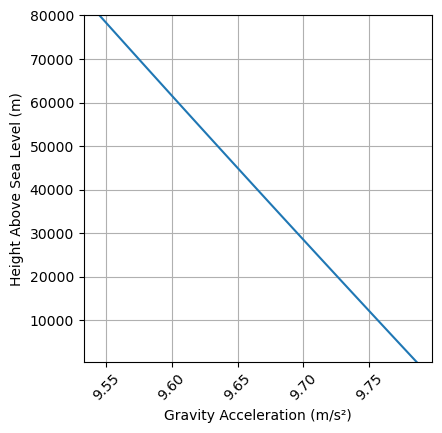



Atmospheric Model Plots


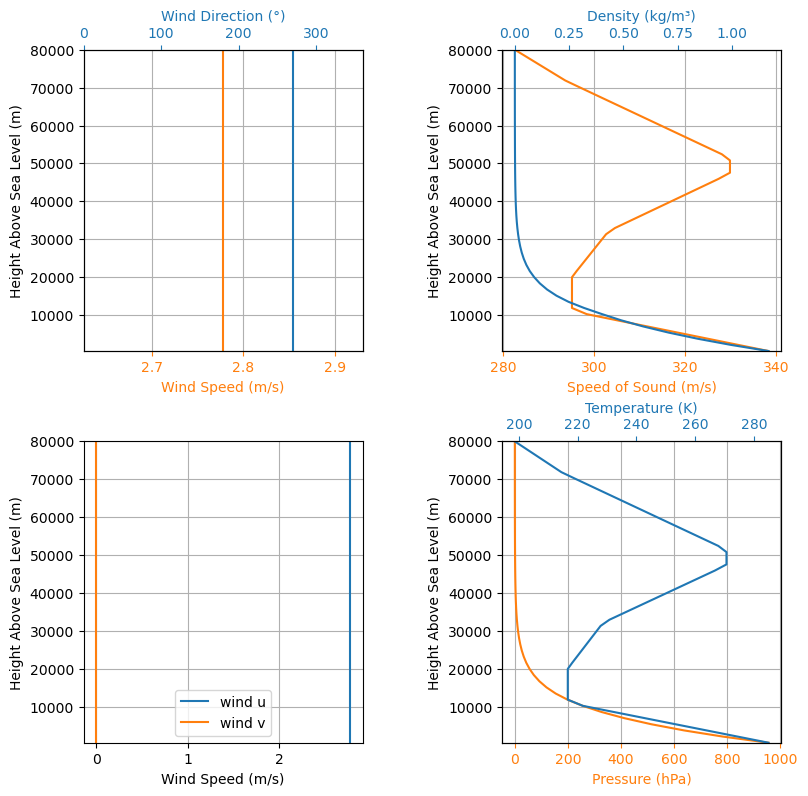

In [5]:
env.all_info()

### Motor

In [6]:
from rocketpy import Fluid, CylindricalTank, MassFlowRateBasedTank, HybridMotor

In [7]:
import csv
#insert correct location for csv files to run the code locally.
liquid_mass=f'C:/Users/pedro/OneDrive/Área de Trabalho/RocketPy - PU4/Data/liquid_mass_curve_2026__455.csv'
vapor_mass=f'C:/Users/pedro/OneDrive/Área de Trabalho/RocketPy - PU4/Data/vapor_mass_curve_2026_455.csv'

flux_time = None

with open(liquid_mass, newline='', encoding="utf-8") as f:
    reader = csv.reader(f)

    for row in reader:
        if not row:          # skip empty lines
            continue
        value = row[0].strip()
        if value == "":      # skip empty first column
            continue
        flux_time = float(value)

print(f'Flux time: {flux_time}')

Flux time: 8.553


In [8]:
# Define the fluids
oxidizer_liq = Fluid(name="N2O_l", density=742.9329783371916)
oxidizer_gas = Fluid(name="N2O_g", density=188.7650429545601)

# Define tank geometry
tank_shape = CylindricalTank(154 / 2000, 0.4034) 

oxidizer_tank = MassBasedTank(
    name = "TANK",
    geometry=tank_shape,
    flux_time=(flux_time), 
    liquid=oxidizer_liq,
    liquid_mass=liquid_mass,
    gas=oxidizer_gas,
    gas_mass=vapor_mass
)

In [9]:
Nybrid = HybridMotor(
    thrust_source="C:/Users/pedro/OneDrive/Área de Trabalho/RocketPy - PU4/Data/Nemesis_Thrust_10_07_2026.csv",
    dry_mass=0,
    dry_inertia=(0, 0, 0),
    center_of_dry_mass_position=0.813,
    grain_number=1,
    grain_separation=0,
    grain_outer_radius= 98 / 2000,
    grain_initial_inner_radius= 50 / 2000,
    grain_initial_height= 300 / 1000,
    grain_density=900,
    nozzle_radius=63.36 / 2000,
    throat_radius=26 / 2000,
    interpolation_method="linear",
    grains_center_of_mass_position=357/1000,
    reshape_thrust_curve=False,
    nozzle_position=0,
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)

In [10]:
Nybrid.add_tank(
  tank = oxidizer_tank, position = (917.5+403.4/2)/1000
)

Nozzle Details
Outlet Radius: 0.03168 m
Throat Radius: 0.013 m
Outlet Area: 0.003153 m²
Throat Area: 0.000531 m²
Position: 0 m

Grain Details
Number of Grains: 1
Grain Spacing: 0 m
Grain Density: 900 kg/m3
Grain Outer Radius: 0.049 m
Grain Inner Radius: 0.025 m
Grain Height: 0.3 m
Grain Volume: 0.002 m3
Grain Mass: 1.506 kg

Motor Details
Total Burning Time: 7.970636455378667 s
Total Propellant Mass: 5.931 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 1645.145 m/s
Average Thrust: 1224.070 N
Maximum Thrust: 3377.0528227097407 N at 0.06863114636337286 s after ignition.
Total Impulse: 9756.613 Ns



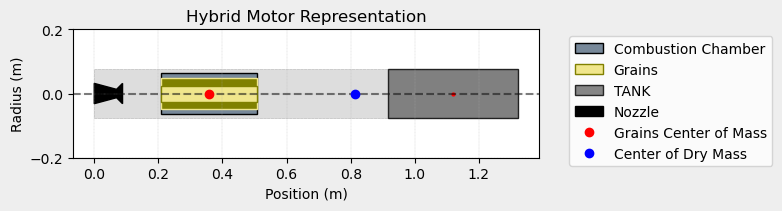

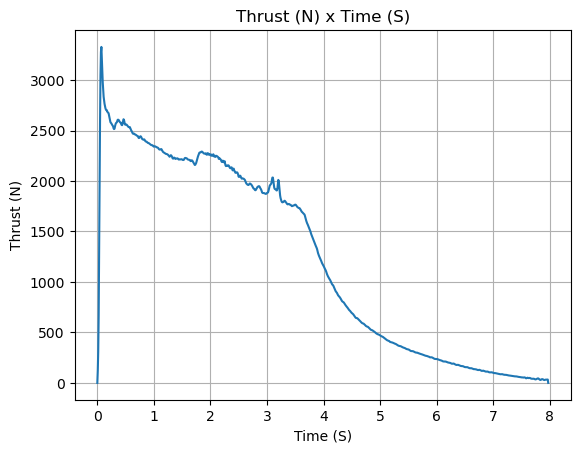

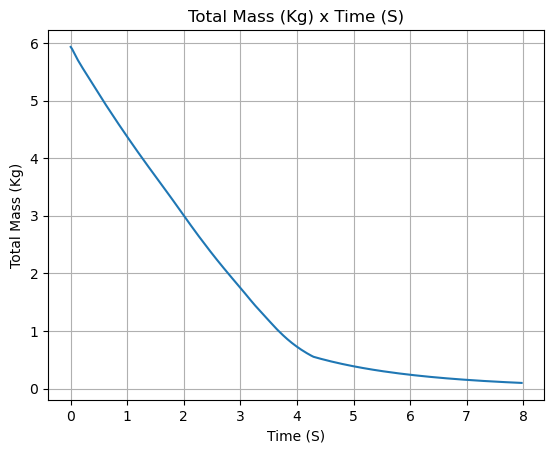

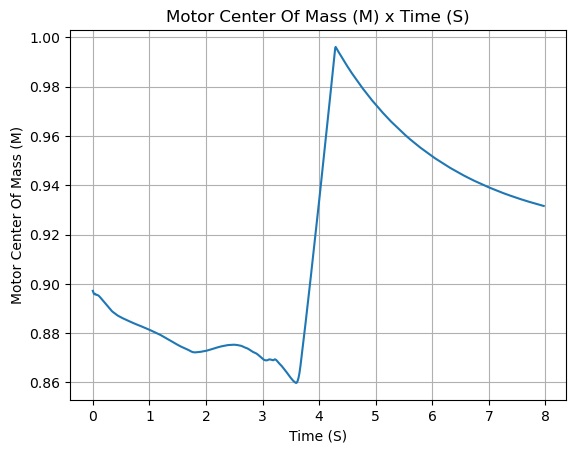

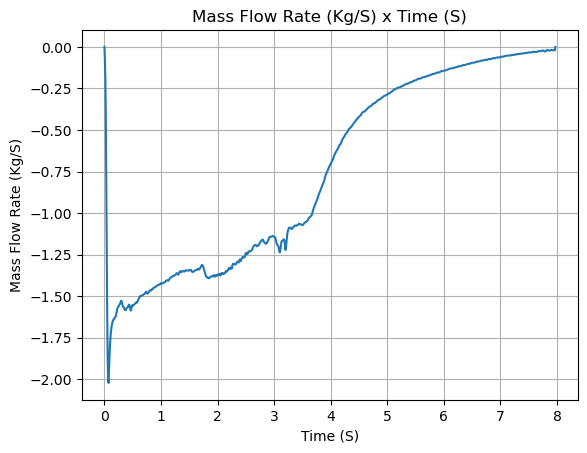

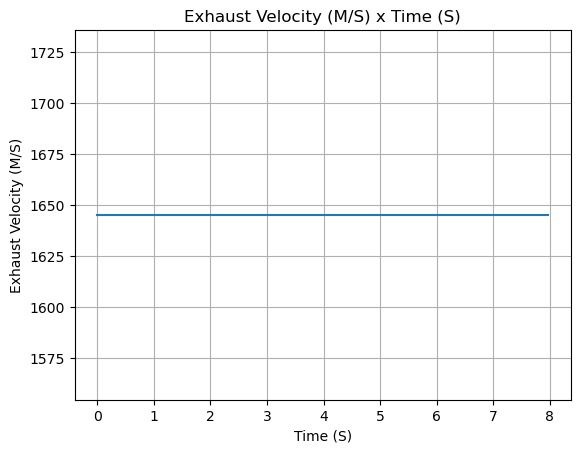

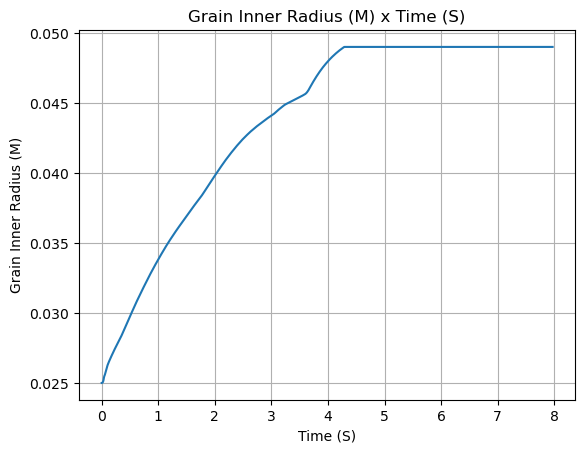

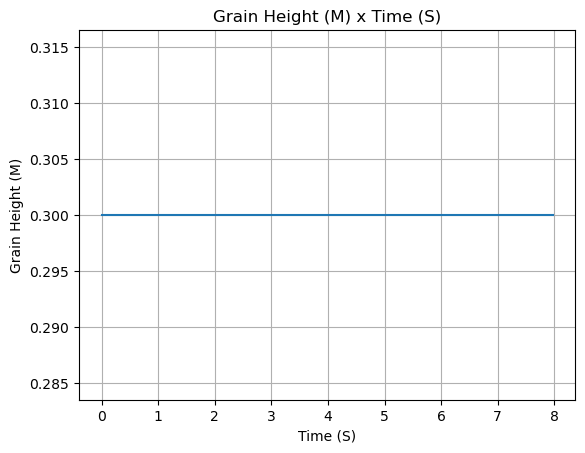

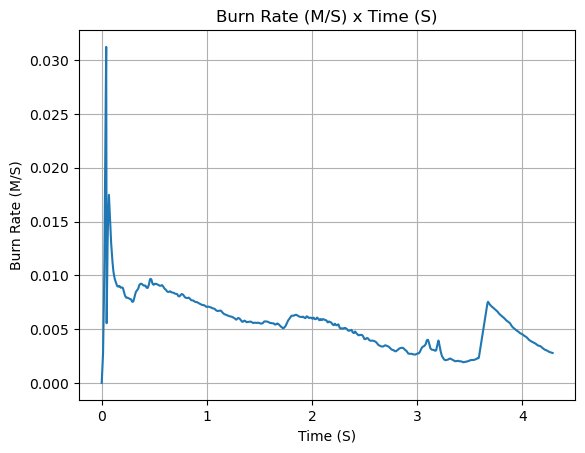

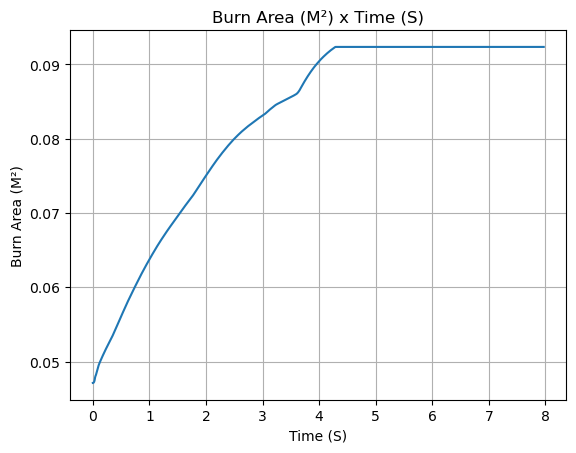

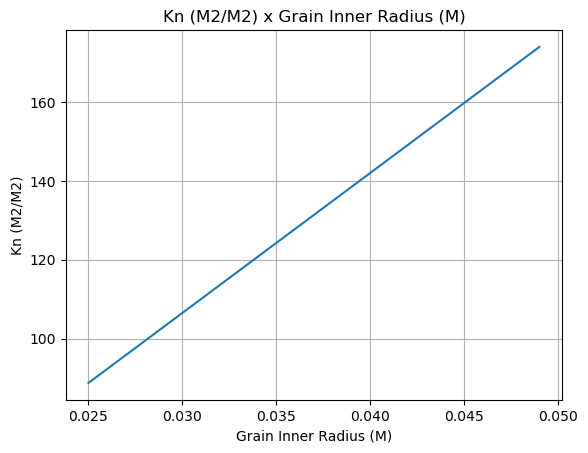

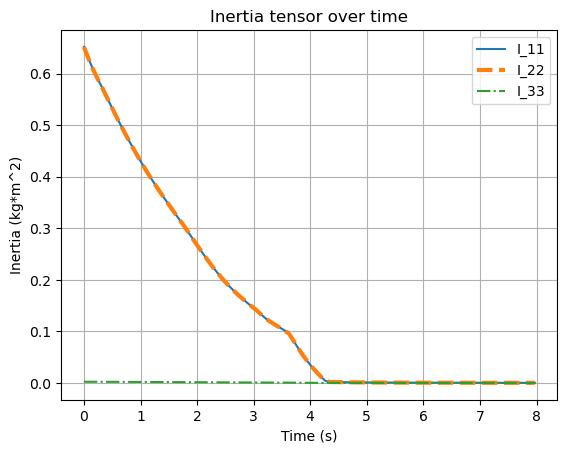

In [11]:
Nybrid.all_info()

### Rocket

In [13]:
Cd_RASAero = "C:/Users/pedro/OneDrive/Área de Trabalho/RocketPy - PU4/Data/CD_RasaeroII_Orion.csv"
Orion = Rocket(
    radius= 0.0817,
    mass=33.619, 
    inertia=(25.494, 25.495, 0.161), 
    power_off_drag= Cd_RASAero,
    power_on_drag= Cd_RASAero,
    center_of_mass_without_motor=2.079, 
    coordinate_system_orientation='nose_to_tail',
    )


rail_buttons = Orion.set_rail_buttons(
    upper_button_position=1.651,
    lower_button_position=3.371,
    angular_position=45,
)

c:\Users\pedro\anaconda3\Lib\site-packages\rocketpy\mathutils\function.py:4101: UserWarning: Interpolation method set to 'spline' because the regular_grid method is not supported.
  warnings.warn(


In [14]:
Orion.add_motor(Nybrid, position=3.393) 

#### Aerodynamic Surfaces

In [15]:
naca0012 = "C:/Users/pedro/OneDrive/Área de Trabalho/RocketPy - PU4/Data/NACA0012-radians.csv"

nose_cone = Orion.add_nose(
      length=0.58763, kind="vonKarman", position=0
    )

fin_set = Orion.add_trapezoidal_fins(
    n=4,
    root_chord=0.135, 
    tip_chord=0.130, 
    span=0.125, 
    position=3.2691, 
    cant_angle=0.5,
    airfoil=(naca0012, "degrees"),
    sweep_length=0.005,
)

tail = Orion.add_tail(
    top_radius=0.0817, bottom_radius=0.06536, length=0.0518, position=3.4244
)

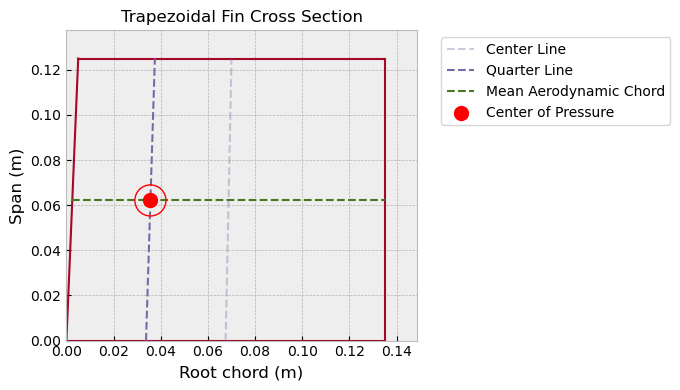

In [16]:
fin_set.draw()

#### Parachutes

In [17]:
Main = Orion.add_parachute(
    "Main",
    cd_s=5.54, 
    trigger=427, 
    sampling_rate=50,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

Drogue = Orion.add_parachute(
    "Drogue",
    cd_s=1.1, 
    trigger="apogee",
    sampling_rate=50,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

#### Rocket Info


Inertia Details

Rocket Mass: 33.619 kg (without motor)
Rocket Dry Mass: 33.619 kg (with unloaded motor)
Rocket Loaded Mass: 39.550 kg
Rocket Structural Mass Ratio: 0.850
Rocket Inertia (with unloaded motor) 11: 25.494 kg*m2
Rocket Inertia (with unloaded motor) 22: 25.495 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.161 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0817 m
Rocket Frontal Area: 0.020970 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.314 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.417 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.063 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 6.532/rad
Tail Lift Coefficient 

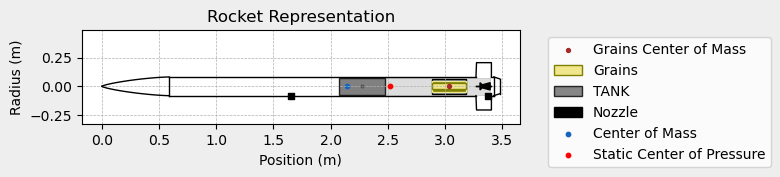


Mass Plots
----------------------------------------


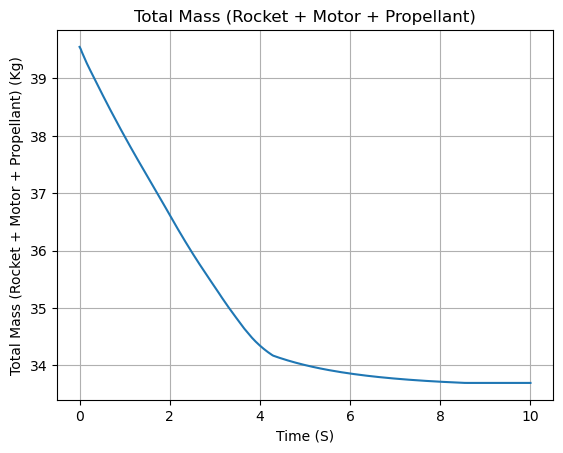

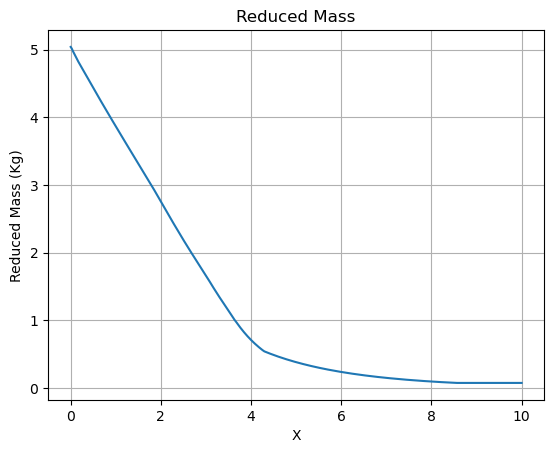


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


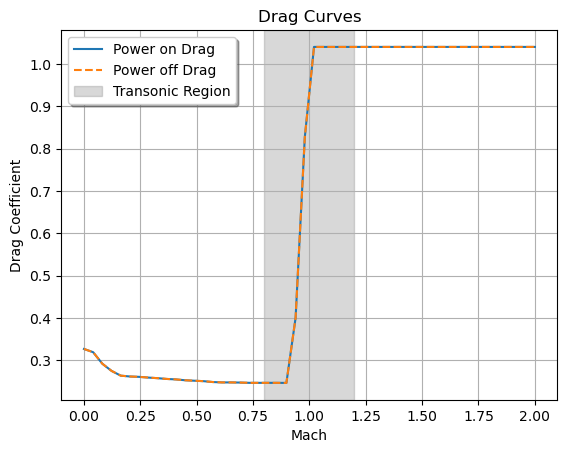


Stability Plots
--------------------


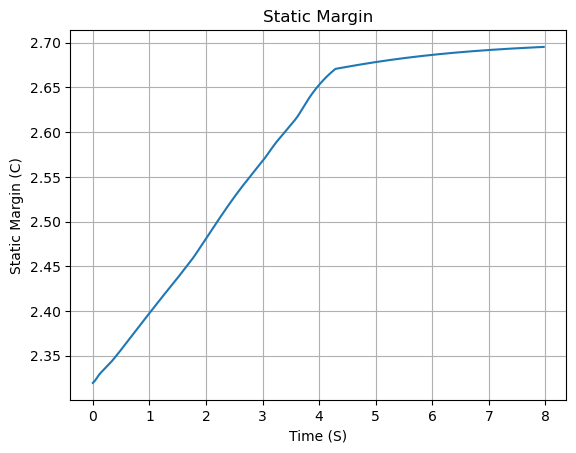

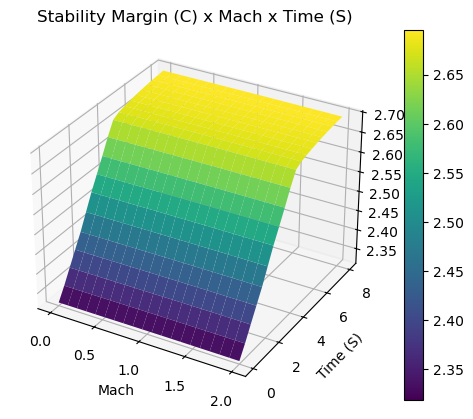


Thrust-to-Weight Plot
----------------------------------------


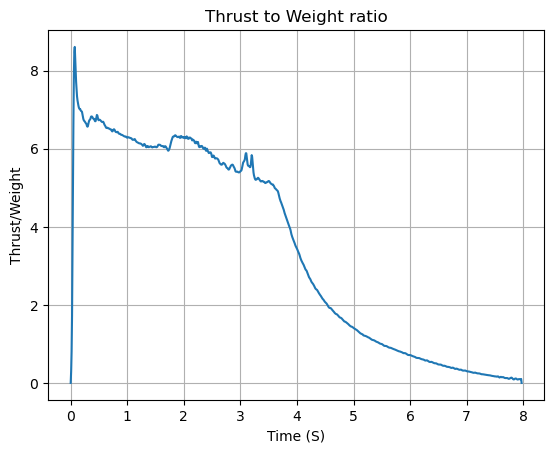

In [18]:
Orion.all_info()

## Simulating the Flight

In [ ]:
test_flight = Flight(
    rocket=Orion, environment=env, rail_length=8.2, inclination=80, heading=90
)

### Results

In [ ]:
test_flight.all_info()